In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import kv, gamma
import numpy.linalg as la
import random

In [4]:
# Constructing the desired matrices

def get_Matern_covariance(data, kappa, s):
    """
    data: N x D array of N vectors x_i in R^D
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation

    Returns a N x N matrix M with M_ij = C_Mat(x_i, x_j)
    """

    dim = data.shape[1]
    nu = s - dim/2
    sigma2 = gamma(nu)/(gamma(s)*(4*np.pi)**(dim/2))
    scalar = sigma2*(2**(1-nu)/gamma(nu))

    # matrix of pairwise distances
    D = kappa*np.linalg.norm(data[:, None] - data[None, :], axis = -1)

    M = np.zeros(D.shape)
    off_diag = (D > 0)
    M[off_diag] = scalar * (D[off_diag] ** nu) * kv(nu, D[off_diag])
    M[~off_diag] = sigma2

    return M

def get_mass_matrix(n_h, L):
    h = L/(n_h-1)
    off_diag = np.repeat(1, n_h-1)
    diag = np.full(n_h, 4)
    diag[0] = diag[-1] = 2
    M = np.diag(off_diag, k=1) + np.diag(diag, k=0) + np.diag(off_diag, k=-1)
    return (h/6)*M

"""
def get_lumped_mass_matrix(M, n_h):
    M = get_mass_matrix(n_h)
    return np.diag(M.sum(axis = 1))
"""


def get_stiffness_matrix(n_h, L):
    h = L/(n_h-1)
    off_diag = np.repeat(-1, n_h-1)
    diag = np.full(n_h, 2)
    diag[0] = diag[-1] = 1
    G = np.diag(off_diag, k=1) + np.diag(diag, k=0) + np.diag(off_diag, k=-1)
    return (1/h)*G

def get_FE_precision_matrix(M, G, kappa, s):
    """
    M: FE mass matrix with M_ij = <e_{h,i}, e_{h,j}>_2
    M_tilde: Lumped FE mass matrix
    G: FE stiffness matrix with G_{ij} = <grad(e_{h,i}), grad(e_{h,j})>_2
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation

    Returns the precision matrix (k^2M + G)[M_tilde^{-1}(k^2M+G)]^{s-1}
    """

    M_tilde = np.diag(M.sum(axis = 1))
    block1 = kappa**2 * M + G
    #print("rank of block1 is {r} and dimension is {d}".format(r = la.matrix_rank(block1), d = block1.shape))
    block2 = la.solve(M_tilde, block1)

    #return la.matmul(block1, block2**(s-1))
    return block1 @ la.matrix_power(block2, s-1)

def get_FE_design_matrix(data, n_h, L):
    """
    data: N x D array of N vectors x_i in R^D

    Return N x n_h finite element design matrix S with S_ij = e_j(X_i)
    """

    K = n_h - 1
    h = L/K
    S = np.zeros((data.shape[0], n_h))
    for i in range(data.shape[0]):
        x_i = data[i,:].item()
        j = int(np.floor(x_i/h)) # get index in the partition
        S[i,j] = -x_i/h + j + 1
        S[i, j+1] = x_i/h - j
    return S

In [5]:
# ground truth and comparison vectors

def get_ground_truth_vector(data, L, kappa, s, M):
    zeta = np.random.multivariate_normal(mean = np.zeros(2*(M+1)), cov = np.eye(2*(M+1)))
    alpha = zeta[:M+1]
    beta = zeta[M+1:]
    cnst = alpha[-1]/(np.sqrt(kappa*L))
    scalar = (np.sqrt(2)*(kappa**(s-0.5)))/np.sqrt(L)

    f_0 = []
    for x in data:
        sum_x = 0
        for i in range(M+1):
            sum_x += ((kappa + ((i*np.pi)/L)**2)**(-s/2))*(alpha[i]*np.cos((i*np.pi*x)/L) + beta[i]*np.sin((i*np.pi*x)/L))
        f_x = cnst + scalar*sum_x
        f_0.append(f_x)

    return np.array(f_0)

In [22]:
np.random.seed(666)

N = 100
L = 5
kappa = 5
s = 2
tau = 2
M = 1000
#n_h = 50

I_N = np.eye(N)

# data generating distribution
data = np.random.uniform(0, L, N)
data = data.reshape((N, 1))
f_0 = get_ground_truth_vector(data, L, kappa, s, M)

y = np.random.multivariate_normal(mean = f_0.reshape(N, ), cov = (tau^2)*I_N)

def generate_data(N, L, n_h, kappa, s, tau):
    """
    N: sample size
    L: upper limit of domain
    n_h: number of finite element basis functions
    kappa: correlation parameter in SPDE formulation
    s: smoothness parameter in SPDE formulation
    tau: standard deviation of likelihood for GP regression

    Returns posterior vectors F_cf, F_fe in R^N with data generated from Uniform(0,L)
    """

    #f_N = f_N.reshape(f_N.shape[0],)

    # Setting 1: Matern covariance
    Sigma = get_Matern_covariance(data, kappa, s)
    #f_N = np.random.multivariate_normal(mean = np.zeros(N), cov = Sigma)
    #y_cf = np.random.multivariate_normal(mean = f_N, cov = (tau^2)*I_N)
    block1 = Sigma + (tau^2)*I_N
    F_cf = Sigma @ la.solve(block1, y)

    # Setting 2: Finite element
    M, G = get_mass_matrix(n_h, L), get_stiffness_matrix(n_h, L)
    Q = get_FE_precision_matrix(M, G, kappa, s)

    S = get_FE_design_matrix(data, n_h, L)

    #w = np.random.multivariate_normal(mean = np.zeros(Q.shape[0]), cov = la.inv(Q))
    #y_fe = np.random.multivariate_normal(mean = S @ w, cov = (tau^2)*I_N)
    block2 = S.T @ S + (tau**2)*Q

    F_fe = S @ la.solve(block2, S.T @ y)

    return np.array([F_cf, F_fe])

In [ ]:
"""
reps = 20

nums = np.arange(2, 200, 5)
nums = [int(num) for num in nums]
errs_cf, errs_fe = [], []
for n_h in nums:
    print(n_h)
    avg_error_cf, avg_error_fe = 0, 0
    for rep in range(reps):
        F = generate_data(N, L, n_h, kappa, s , tau, f_0)
        F_cf = F[0,:]
        F_fe = F[1,:]

        avg_error_cf += la.norm(F_cf - f_0)/N
        avg_error_fe += la.norm(F_fe - f_0)/N

    errs_cf.append(avg_error_cf/reps)
    errs_fe.append(avg_error_fe/reps)

plot_data = np.array([nums, errs_cf, errs_fe])
plt.plot(plot_data[0], plot_data[1])
plt.plot(plot_data[0], plot_data[2])
"""

2 1.9879806661728576 3.0102471184279413
7 1.9879806661728576 3.00999617282513
12 1.9879806661728576 3.0088596131404386
17 1.9879806661728576 3.0092672802236704
22 1.9879806661728576 3.009178121453282
27 1.9879806661728576 3.009211827509116
32 1.9879806661728576 3.009227839870006
37 1.9879806661728576 3.0092327485092984
42 1.9879806661728576 3.0092602247561406
47 1.9879806661728576 3.0092515174102403
52 1.9879806661728576 3.009255440332502
57 1.9879806661728576 3.0092629362151366
62 1.9879806661728576 3.0092583349340436
67 1.9879806661728576 3.009254340518978
72 1.9879806661728576 3.009260137371119
77 1.9879806661728576 3.009266391174256
82 1.9879806661728576 3.009259504986456
87 1.9879806661728576 3.0092659859763846
92 1.9879806661728576 3.0092652207701294
97 1.9879806661728576 3.0092645880739552
102 1.9879806661728576 3.0092670202821012
107 1.9879806661728576 3.009265212230712
112 1.9879806661728576 3.0092659637921626
117 1.9879806661728576 3.0092680248385864
122 1.9879806661728576 3.

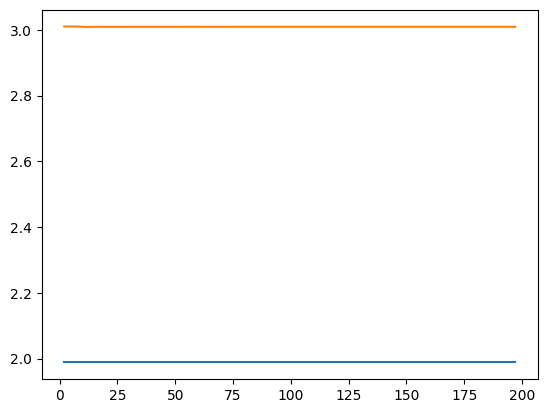

In [23]:
nums = np.arange(2, 200, 5)
errors_cf, errors_fe = [], []
for n_h in nums:
    F = generate_data(N, L, n_h, kappa, s, tau)
    F_cf, F_fe = F[0,:], F[1,:]
    errors_cf.append(la.norm(F_cf - f_0)/N)
    errors_fe.append(la.norm(F_fe - f_0)/N)
    print(n_h, errors_cf[-1], errors_fe[-1])

plot_data = np.array([nums, errors_cf, errors_fe])
plt.plot(plot_data[0], plot_data[1])
plt.plot(plot_data[0], plot_data[2])
plt.show()

In [20]:
max(plot_data[1]) - min(plot_data[1])

np.float64(0.001387505287502755)